In [1]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
TB_DIR = Path.cwd() / "results/out_TL/tb_TL"
TAG = "A_Mean NLL loss"
SMOOTHING = 0.6
RUNS = [("Training Loss", "#00B8D9"), ("Validation Loss", "#FFA500"), ("Sample Loss", "#FF1493")]

def tensorboard_smooth(values, weight=SMOOTHING):
    accumulator = 0.0
    result = []
    for index, value in enumerate(values, start=1):
        accumulator = weight * accumulator + (1 - weight) * value
        result.append(accumulator / (1 - weight ** index))
    return np.asarray(result)

runs = []
for name, color in RUNS:
    run_name = f"{TAG}_{name}"
    events = EventAccumulator(
        str(TB_DIR / run_name), size_guidance={"scalars": 0}
    ).Reload().Scalars(TAG)
    steps = np.asarray([event.step for event in events])
    values = np.asarray([event.value for event in events])
    runs.append({
        "name": run_name,
        "color": color,
        "steps": steps,
        "values": values,
        "smoothed": tensorboard_smooth(values),
        "relative": events[-1].wall_time - events[0].wall_time,
    })

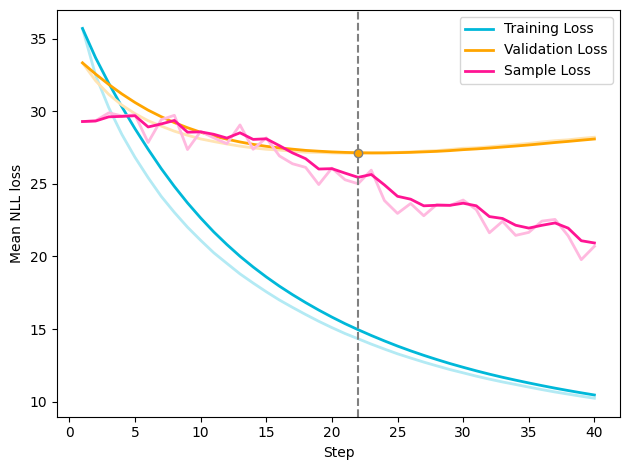

In [3]:
fig, ax = plt.subplots()

for run in runs:
    name = run["name"].removeprefix(f"{TAG}_")
    ax.plot(run["steps"], run["values"], color=0.3 * np.array(mcolors.to_rgb(run["color"])) + 0.7, linewidth=2)
    ax.plot(run["steps"], run["smoothed"], color=run["color"], linewidth=2, label=name)

valid = next(run for run in runs if run["name"] == f"{TAG}_Validation Loss")
valid_min_idx = np.argmin(valid["values"])

ax.axvline(x=valid["steps"][valid_min_idx], color="gray", linestyle="--")
ax.scatter(valid["steps"][valid_min_idx], valid["values"][valid_min_idx], color=valid["color"], edgecolor="gray", zorder=5)

ax.set_xlabel("Step")
ax.set_ylabel("Mean NLL loss")
ax.legend(frameon=True)

fig.tight_layout()
fig.savefig("results/TL_Mean_NLL_loss.png", dpi=300)
plt.show()